## 3.1 Markovian drone

**(a)**

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

n=20
drone_pos=np.array((0,0))
goal_pos=np.array((19,9))
x_eye=np.array((15,15))
sigma=10
gamma=0.95

actions={"up": np.array((0,1)),
         "down": np.array((0,-1)),
         "left": np.array((-1,0)),
         "right": np.array((1,0))}  


def move_drone(pos,action):
    new_pos=pos+actions[action]
    if (0<=new_pos[0]<n) and (0<=new_pos[1]<n):
        return new_pos
    else:
        return pos

def get_reward(pos):
    return float(np.all(pos==goal_pos))

def get_neighboring_positions(pos):
    neighbors={}
    for action in actions.keys():
        neighbors[action]=move_drone(pos,action)
    return neighbors

def w(pos,x_eye):
    distance=np.linalg.norm(pos-x_eye)
    return np.exp(-distance**2/(2*sigma**2))

def is_intended_action(action,intent):
    return action==intent

def bellman_update(V):
    V_new=np.zeros_like(V)
    for x in range(n):
        for y in range(n):
            pos=np.array((x,y))
            storm_prob=w(pos,x_eye)
            neighbors=get_neighboring_positions(pos)
            best_value=-np.inf
            for intent in actions.keys():
                value_candidate=sum(
                    (storm_prob/4 + (1-storm_prob)*is_intended_action(a,intent))*(get_reward(neighbors[a]) + gamma*V[tuple(neighbors[a])])
                    for a in actions.keys()
                )
                if value_candidate>best_value:
                    best_value=value_candidate
            V_new[x,y]=best_value
    return V_new

Converged in 319 iterations, peak V* = 4.402236


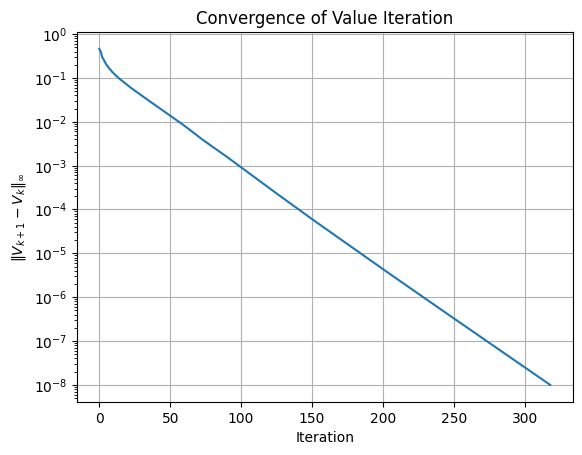

In [2]:
V = np.zeros((n, n))
history = []
for i in range(500):
    V_new = bellman_update(V)
    diff = np.max(np.abs(V_new - V))
    history.append(diff)
    V = V_new
    if diff < 1e-8:
        break

print(f"Converged in {len(history)} iterations, peak V* = {V.max():.6f}")

plt.plot(history)
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel(r'$\|V_{k+1} - V_k\|_\infty$')
plt.title('Convergence of Value Iteration')
plt.grid()
plt.show()

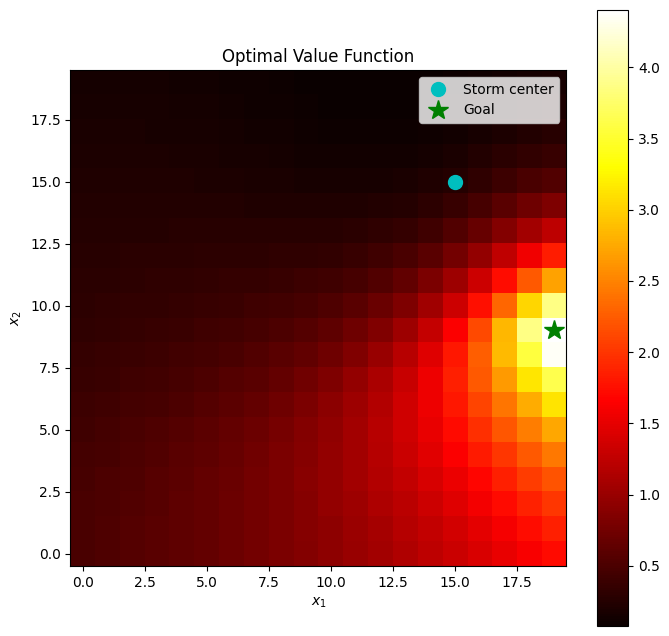

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(V.T, origin='lower', cmap='hot')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Optimal Value Function')
ax.plot(x_eye[0], x_eye[1], 'co', markersize=10, label='Storm center')
ax.plot(goal_pos[0], goal_pos[1], 'g*', markersize=15, label='Goal')
ax.legend()
plt.colorbar(im, ax=ax)
plt.show()

**(b)**

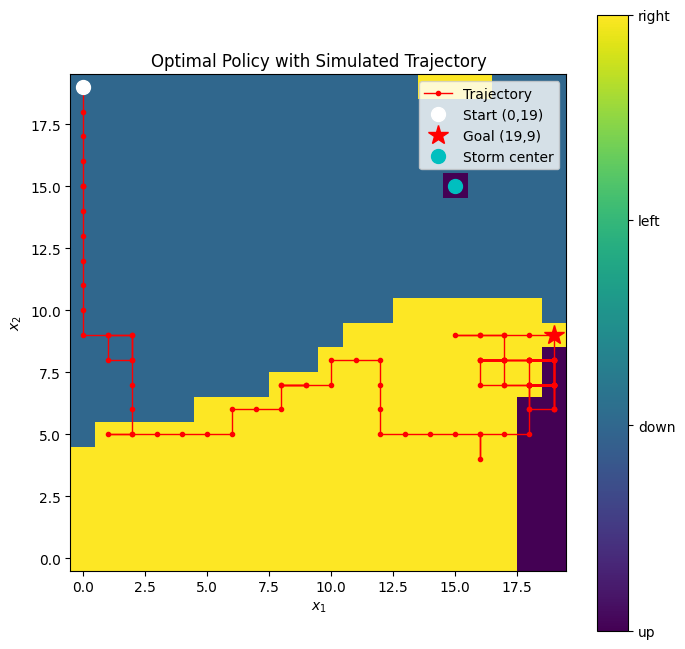

In [4]:
action_names = list(actions.keys())
policy = np.zeros((n, n), dtype=int)

for x in range(n):
    for y in range(n):
        pos = np.array((x, y))
        storm_prob = w(pos, x_eye)
        neighbors = get_neighboring_positions(pos)
        best_value = -np.inf
        for idx, intent in enumerate(action_names):
            value_candidate = sum(
                (storm_prob/4 + (1 - storm_prob) * is_intended_action(a, intent)) *
                (get_reward(neighbors[a]) + gamma * V[tuple(neighbors[a])])
                for a in action_names
            )
            if value_candidate > best_value:
                best_value = value_candidate
                policy[x, y] = idx

# Simulate from (0, 19) for 100 steps
np.random.seed(42)
pos = np.array([0, 19])
trajectory = [pos.copy()]
for _ in range(100):
    action = action_names[policy[pos[0], pos[1]]]
    omega = w(pos, x_eye)
    if np.random.rand() < omega:
        action = np.random.choice(action_names)
    pos = move_drone(pos, action)
    trajectory.append(pos.copy())
trajectory = np.array(trajectory)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(policy.T, origin='lower', cmap='viridis')
ax.plot(trajectory[:, 0], trajectory[:, 1], 'r-o', markersize=3, linewidth=1, label='Trajectory')
ax.plot(trajectory[0, 0], trajectory[0, 1], 'wo', markersize=10, label='Start (0,19)')
ax.plot(goal_pos[0], goal_pos[1], 'r*', markersize=15, label='Goal (19,9)')
ax.plot(x_eye[0], x_eye[1], 'co', markersize=10, label='Storm center')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Optimal Policy with Simulated Trajectory')
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3])
cbar.set_ticklabels(['up', 'down', 'left', 'right'])
ax.legend()
plt.show()

The policy steers the drone toward the goal at $(19, 9)$ while routing around the storm center at $(15, 15)$. Far from the storm, the drone moves directly toward the goal. Near the eye, $\omega(x)$ is high, so any intended action has a large chance of being overridden by a uniformly random kick; in expectation that random kick costs more discounted reward than the longer detour, so the optimal policy routes around the high-$\omega$ region from below rather than through it.